# Description
Analyze the output from the analytic model and compare to observations. (Note that the name of this notebook is outdated, but kept as is for consistency with personal notes; PN)

# Plotting preferences

In [1]:
supTitleFontSize = 16
titleFontSize = 12

# Load analysis functions

In [1]:
%run ...../imports.ipynb
%run ...../analysisScripts/snotelAnalysisFunctions.ipynb

# Load data

add choice for loading all stations or just biased corrected stations...

In [3]:
stationBiasDict = loadTempBiasMarker()

In [4]:
rootPath = '...../snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [5]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|██████████| 13/13 [00:14<00:00,  1.15s/it]


In [6]:
## Filter stations for consistent analysis ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

In [7]:
## Print number of stations and other information ##
count = 0
numberOfStates = 0
numberOfYearsTotal = 0
for istate,stateName in enumerate(stateNames):
    stations = allStateDict_filtered[stateName]
    for stat in stations:
        numberOfYearsTotal = numberOfYearsTotal + len(np.unique(stat.water_year.values))
    count = count + len(stations)
    if len(stations)>0:
        numberOfStates = numberOfStates + 1
    elif len(stations)==0:
        print(stateName)
        
print(f'Number of stations = {count}')
print(f'Number of states = {numberOfStates}')
print(f'Number of water years = {numberOfYearsTotal}')

SD
Number of stations = 506
Number of states = 12
Number of water years = 12910


# Model: Winter prcp rate and $\tau_\text{F}$

The $P_\text{w}\tau_\text{F}$ from the paper.

In [8]:
allStateDict_prcpRate_tauF = winterPrcpRateByYear(stateNames,allStateDict_filtered,accumThresh = 0)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM']: 3/27         

/tmp/ipykernel_1591/132286664.py:58: RuntimeWarning: invalid value encountered in scalar divide
  P_duringSnow = np.sum(currPInterp[firstSnowInd:indMax])/tMax_tStart_days


['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [9]:
stationMeanPrcpRate = np.array([])
#allPrcpRateDeviation = np.array([])
stationMeanTauF = np.array([])
stationMeanFreezeStreak = np.array([])
stationMeanTw = np.array([])
#allTauFDeviation = np.array([])
stationMeanPeakSWE = np.array([])
allPeakSWEDev = np.array([])
allTaylorApproxPeakSWEDev = np.array([])
allTaylorApproxPeakSWEDev_linear = np.array([])
allTaylorApproxPeakSWEDev_fxdFrzLen = np.array([])
allTaylorApproxPeakSWEDev_fxdPrcpRate = np.array([])
stationNumbers = np.array([])

for istate,stateName in enumerate(stateNames):
    stations = allStateDict_prcpRate_tauF[stateName]
    if len(stations)>0:
        for stat in stations:
            # Calculate mean values
            currStatMeanPrcpRate = np.mean(stat.precipRates)
            currStatMeanTauF = np.mean(stat.numDaysBelowTThresh_s)
            currStatMeanPeakSWE = np.mean(stat.peakSWE)
            currStatMeanFreezeStreak = np.mean(stat.longestFreezeStreak)
            currStatMeanTw = np.mean(stat.Tw)
            # Calculate deviations
            currStatPrcpRateDev = stat.precipRates-currStatMeanPrcpRate
            currStatTauFDev = stat.numDaysBelowTThresh_s-currStatMeanTauF
            currStatPeakSWEDev = stat.peakSWE-currStatMeanPeakSWE
            # Calculate Taylor Expansion Approx
            term1 = currStatPrcpRateDev*currStatMeanTauF
            term2 = currStatTauFDev*currStatMeanPrcpRate
            term3 = currStatPrcpRateDev*currStatTauFDev
            currStatTaylorApprox = term1+term2+term3

            # Append to array
            stationMeanPrcpRate = np.append(stationMeanPrcpRate,currStatMeanPrcpRate)
            stationMeanTauF = np.append(stationMeanTauF,currStatMeanTauF)
            stationMeanFreezeStreak = np.append(stationMeanFreezeStreak,currStatMeanFreezeStreak)
            stationMeanTw = np.append(stationMeanTw,currStatMeanTw)
            stationMeanPeakSWE = np.append(stationMeanPeakSWE,currStatMeanPeakSWE)
            allPeakSWEDev = np.append(allPeakSWEDev,currStatPeakSWEDev)
            allTaylorApproxPeakSWEDev = np.append(allTaylorApproxPeakSWEDev,currStatTaylorApprox)
            allTaylorApproxPeakSWEDev_linear = np.append(allTaylorApproxPeakSWEDev_linear,term1+term2)
            allTaylorApproxPeakSWEDev_fxdFrzLen = np.append(allTaylorApproxPeakSWEDev_fxdFrzLen,term1)
            allTaylorApproxPeakSWEDev_fxdPrcpRate = np.append(allTaylorApproxPeakSWEDev_fxdPrcpRate,term2)
            stationNumbers = np.append(stationNumbers,stat.number)

In [10]:
# Which form of the decomposition do you want to look at?
decompChoice = 'full' # full, linear, fxdFrzLen, fxdPrcpRate

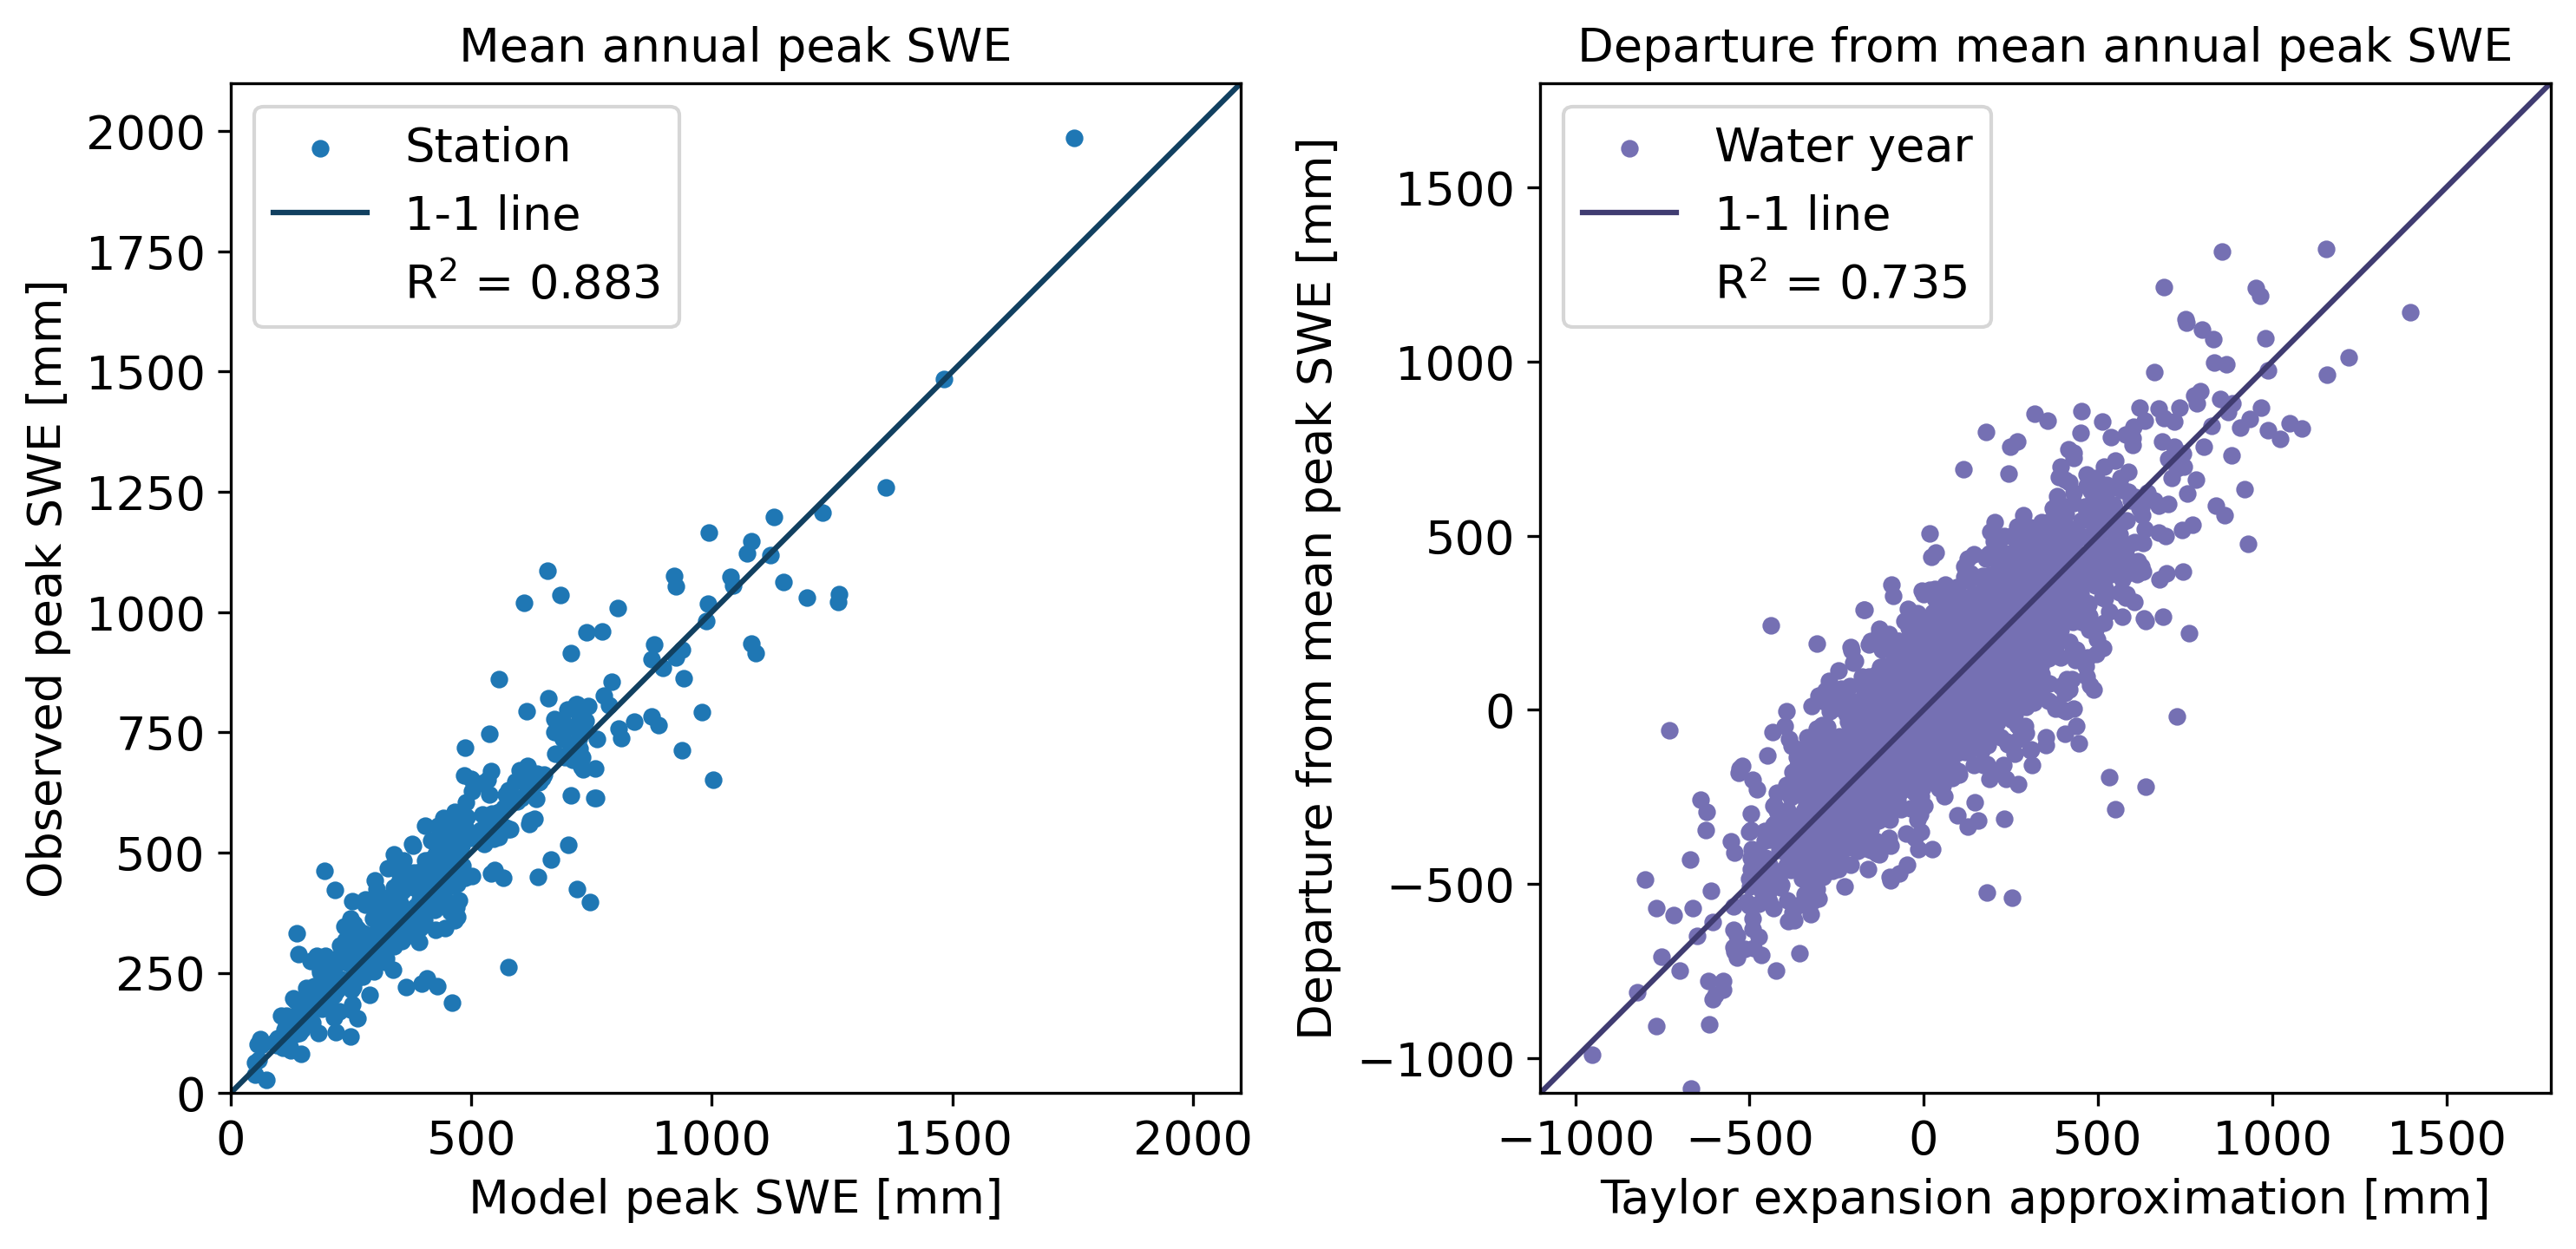

In [11]:
### Plot ###
if decompChoice == 'full':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev
    yData1 = allPeakSWEDev
    decompName = 'Full decomposition'
elif decompChoice == 'linear':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_linear
    yData1 = allPeakSWEDev
    decompName = 'Linear decomposition'
elif decompChoice == 'fxdFrzLen':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_fxdFrzLen
    yData1 = allPeakSWEDev
    decompName = 'Fixed frozen season length'
elif decompChoice == 'fxdPrcpRate':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_fxdPrcpRate
    yData1 = allPeakSWEDev
    decompName = 'Fixed winter prcp rate'


fig = plt.figure(figsize=(10,5.2),dpi=300)
figFontSize = 13

#### Model vs obs climatological peak SWE ####
ax0 = plt.subplot(1,2,1)
ax0.scatter(xData0,yData0,15,label='Station')
ax0.set_ylabel('Observed peak SWE [mm]',fontsize=figFontSize)
ax0.set_xlabel('Model peak SWE [mm]',fontsize=figFontSize)
ax0.axis('square')
ax0.set_xlim([0,2100])
ax0.set_ylim([0,2100])
ax0.set_title('Mean annual peak SWE',fontsize=figFontSize)
#ax0.text(0,2150,'(a)',fontsize=titleFontSize)

## Plot 1-1 line ##
ax0.plot(np.arange(0,2100),np.arange(0,2100),c='#114060',label='1-1 line')
thisR2 = R2_from1to1(xData0,yData0)
ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
ax0.legend(fontsize=figFontSize)

ax0.tick_params(axis='both', labelsize=figFontSize)

## least squares best fit line (not shown) ##
# slope,R2 = leastSquaresSlope(xData0,yData0)
# ax0.plot(xData,xData*slope,c='#114060',label='Least squares best fit')
# ax0.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# ax0.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# ax0.legend()

#### Model vs obs deviation from climatological SWE ####
ax1 = plt.subplot(1,2,2)
ax1.scatter(xData1,yData1,15,c='#7570b3',label='Water year')
ax1.set_ylabel('Departure from mean peak SWE [mm]',fontsize=figFontSize)
ax1.set_xlabel('Taylor expansion approximation [mm]',fontsize=figFontSize)
ax1.axis('square')
ax1.set_xlim([-1100,1800])
ax1.set_ylim([-1100,1800])
ax1.set_title('Departure from mean annual peak SWE',fontsize=figFontSize)
#ax1.text(-1100,1850,'(b)',fontsize=titleFontSize)

## Plot 1-1 line ##
ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#403c71',label='1-1 line')
thisR2 = R2_from1to1(xData1,yData1)
ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
ax1.legend(fontsize=figFontSize)

ax1.tick_params(axis='both', labelsize=figFontSize)

plt.tight_layout()
# Winter mean precipitation rate times frozen season length ## old title


In [12]:
## Save for final plot ##
saveBool = False
if saveBool:
    pathToSave = '...../figureData'
    np.savez(pathToSave + '/figure3Analytic.npz', analyticStation=stationMeanPrcpRate*stationMeanTauF,
             analyticWY = allTaylorApproxPeakSWEDev,
             obsStation = stationMeanPeakSWE,
             obsWY = allPeakSWEDev)

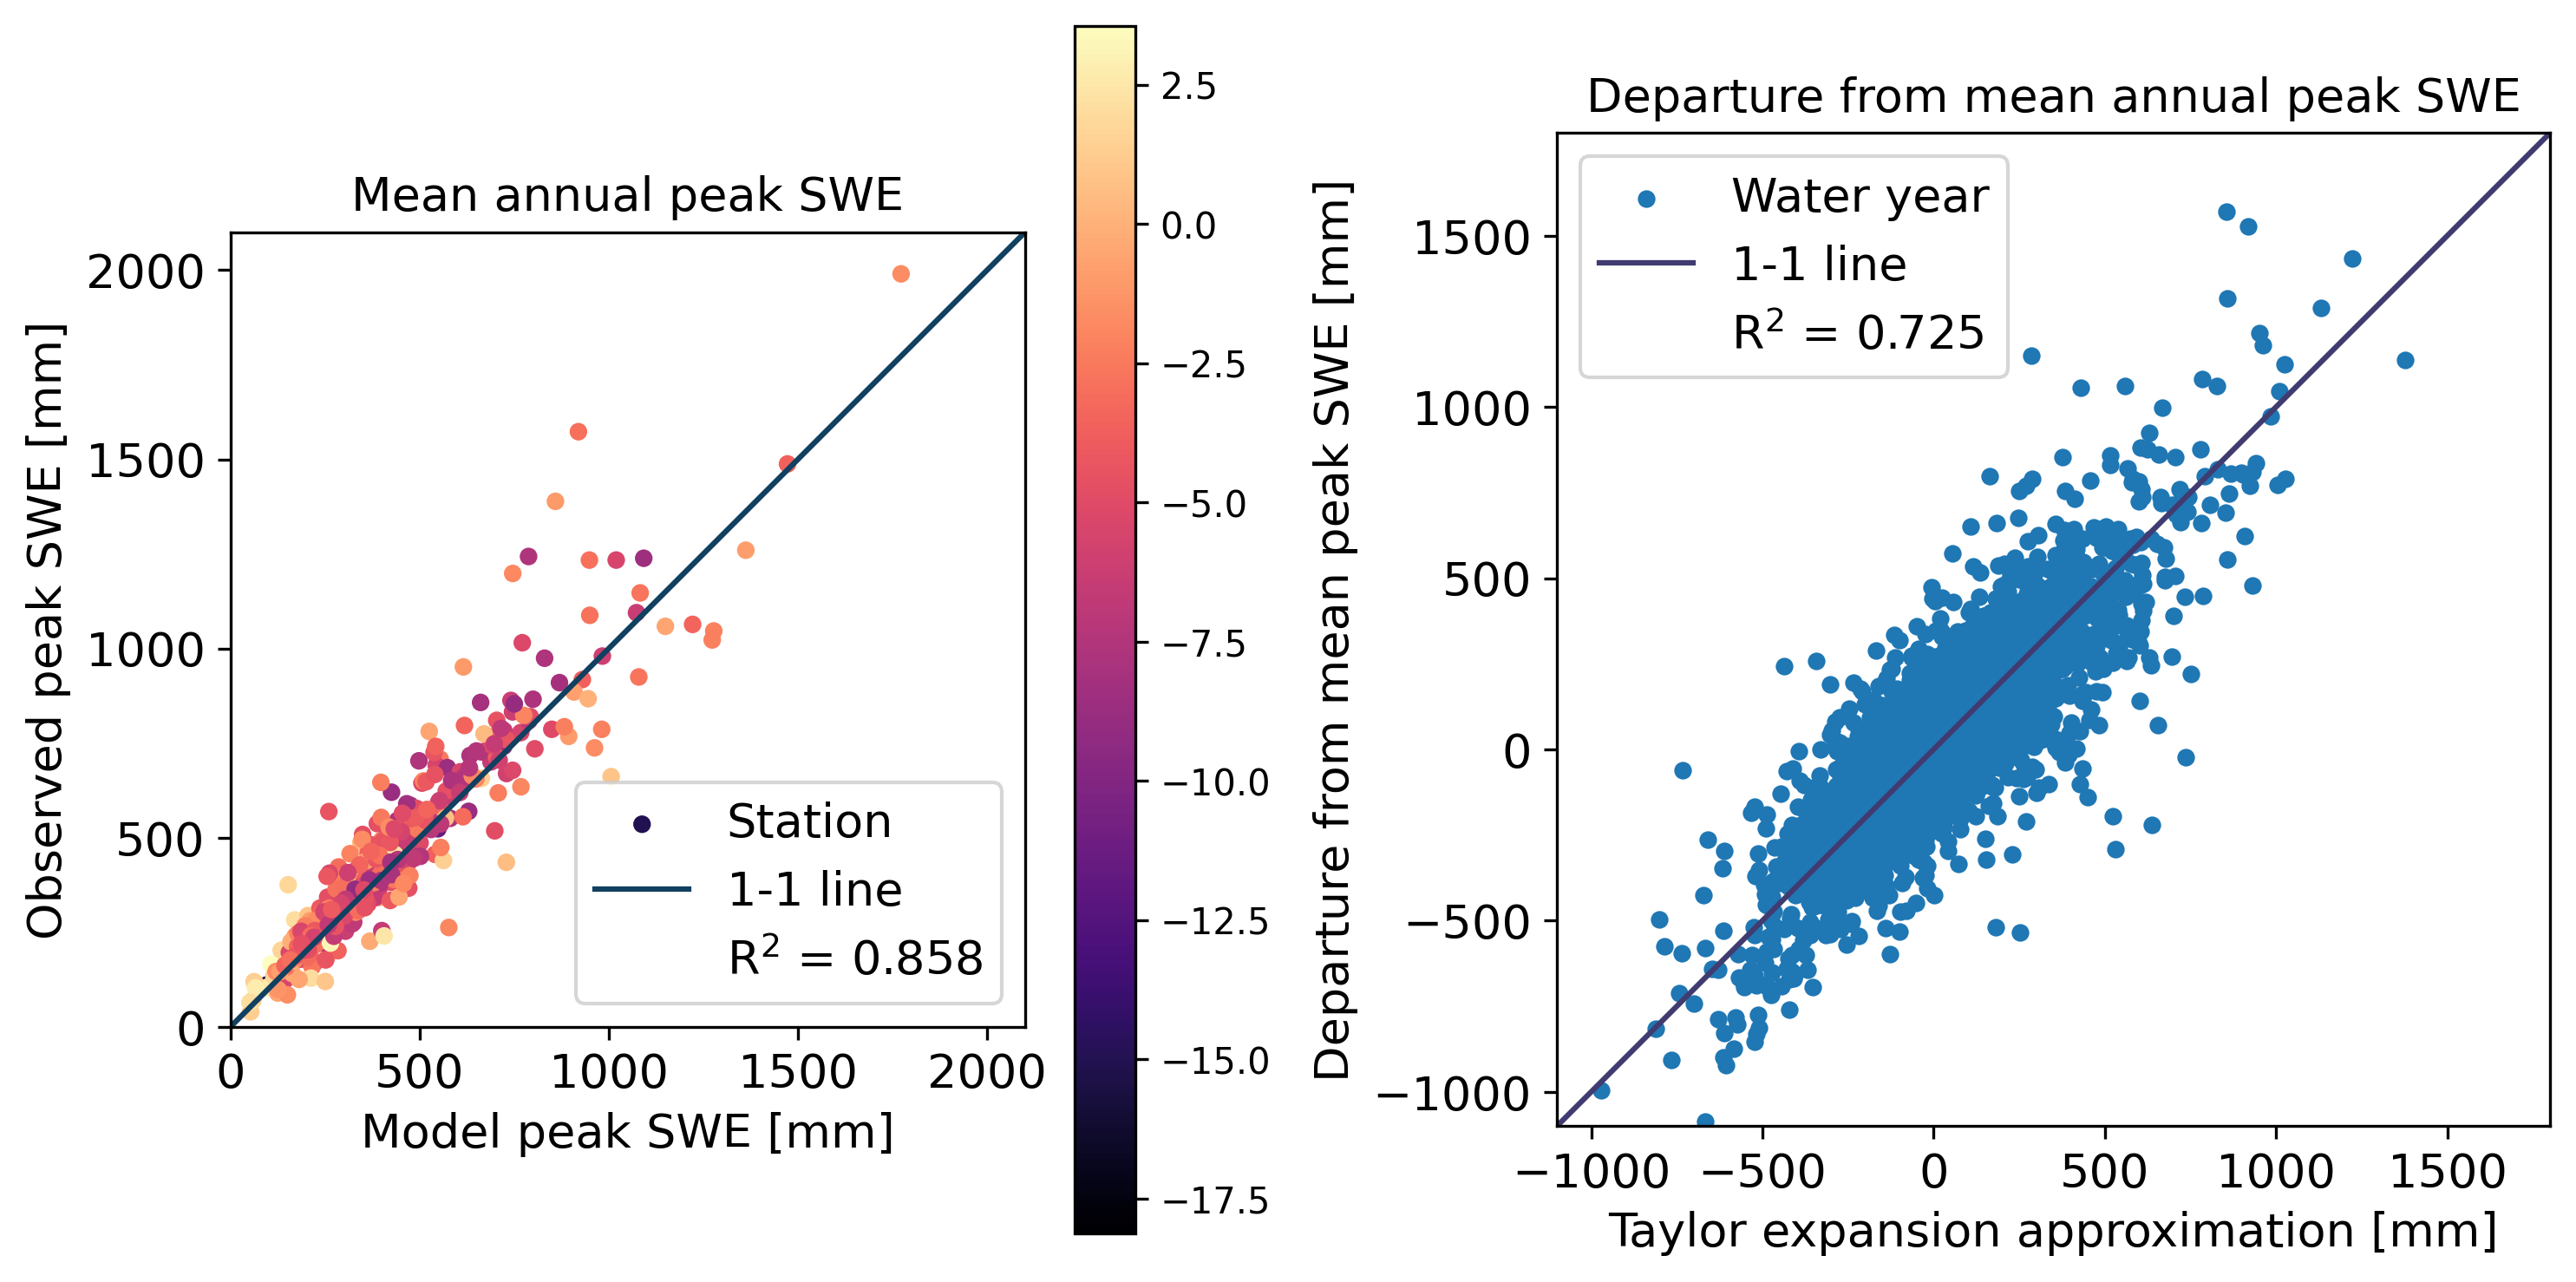

In [25]:
### Plot ###
if decompChoice == 'full':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev
    yData1 = allPeakSWEDev
    decompName = 'Full decomposition'
elif decompChoice == 'linear':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_linear
    yData1 = allPeakSWEDev
    decompName = 'Linear decomposition'
elif decompChoice == 'fxdFrzLen':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_fxdFrzLen
    yData1 = allPeakSWEDev
    decompName = 'Fixed frozen season length'
elif decompChoice == 'fxdPrcpRate':
    xData0 = stationMeanPrcpRate*stationMeanTauF
    yData0 = stationMeanPeakSWE
    xData1 = allTaylorApproxPeakSWEDev_fxdPrcpRate
    yData1 = allPeakSWEDev
    decompName = 'Fixed winter prcp rate'


fig = plt.figure(figsize=(10,5.2),dpi=300)
figFontSize = 13

#### Model vs obs climatological peak SWE ####
ax0 = plt.subplot(1,2,1)
im = ax0.scatter(xData0,yData0,15,label='Station',c=stationMeanTw,cmap = 'magma')
fig.colorbar(im)
ax0.set_ylabel('Observed peak SWE [mm]',fontsize=figFontSize)
ax0.set_xlabel('Model peak SWE [mm]',fontsize=figFontSize)
ax0.axis('square')
ax0.set_xlim([0,2100])
ax0.set_ylim([0,2100])
ax0.set_title('Mean annual peak SWE',fontsize=figFontSize)
#ax0.text(0,2150,'(a)',fontsize=titleFontSize)

## Plot 1-1 line ##
ax0.plot(np.arange(0,2100),np.arange(0,2100),c='#114060',label='1-1 line')
thisR2 = R2_from1to1(xData0,yData0)
ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
ax0.legend(fontsize=figFontSize)

ax0.tick_params(axis='both', labelsize=figFontSize)

## least squares best fit line (not shown) ##
# slope,R2 = leastSquaresSlope(xData0,yData0)
# ax0.plot(xData,xData*slope,c='#114060',label='Least squares best fit')
# ax0.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# ax0.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# ax0.legend()

#### Model vs obs deviation from climatological SWE ####
ax1 = plt.subplot(1,2,2)
ax1.scatter(xData1,yData1,15,label='Water year')
ax1.set_ylabel('Departure from mean peak SWE [mm]',fontsize=figFontSize)
ax1.set_xlabel('Taylor expansion approximation [mm]',fontsize=figFontSize)
ax1.axis('square')
ax1.set_xlim([-1100,1800])
ax1.set_ylim([-1100,1800])
ax1.set_title('Departure from mean annual peak SWE',fontsize=figFontSize)
#ax1.text(-1100,1850,'(b)',fontsize=titleFontSize)

## Plot 1-1 line ##
ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#403c71',label='1-1 line')
thisR2 = R2_from1to1(xData1,yData1)
ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
ax1.legend(fontsize=figFontSize)

ax1.tick_params(axis='both', labelsize=figFontSize)

## least squares best fit line (not shown) ##
# slope,R2 = leastSquaresSlope(xData,yData)
# ax1.plot(xData,xData*slope,c='#403c71',label='Least squares best fit')
# ax1.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# ax1.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# ax1.legend()

#fig.suptitle(f' Analytic peak SWE model \n {decompName}',fontsize=supTitleFontSize)
plt.tight_layout()
# Winter mean precipitation rate times frozen season length ## old title


## Demonstrate relationship between $P_w$ and $P$ on days below freezing

In [13]:
prcpDict = winterPrcpRateByYear(stateNames,allStateDict_filtered)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM']: 3/27         

/tmp/ipykernel_1591/132286664.py:58: RuntimeWarning: invalid value encountered in scalar divide
  P_duringSnow = np.sum(currPInterp[firstSnowInd:indMax])/tMax_tStart_days


['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [14]:
pwAll = np.array([])
pwMean = np.array([])
pTauFAll = np.array([])
pTauFMean = np.array([])
for istate,stateName in enumerate(stateNames):
    stations = prcpDict[stateName]
    if len(stations)>0:
        for stat in stations:
            pw = stat.precipRates
            pTauF = stat.prcpDuringTauF
            pwAll = np.append(pwAll,pw)
            pwMean = np.append(pwMean,np.mean(pw))
            pTauFAll = np.append(pTauFAll,pTauF)
            pTauFMean = np.append(pTauFMean,np.mean(pTauF))

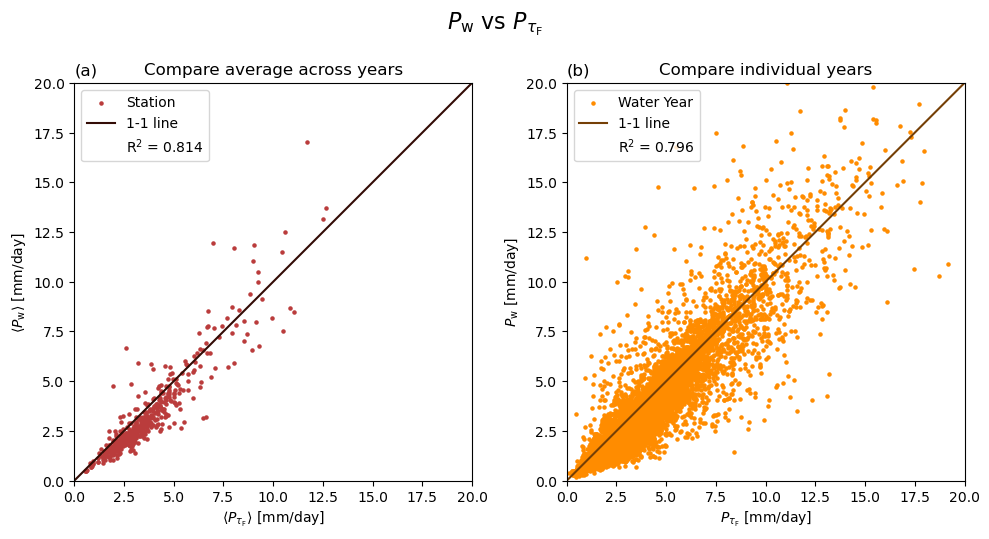

In [15]:
### Plot ###

fig = plt.figure(figsize=(10,5.4))

#### Mean accross years ####
ax0 = plt.subplot(1,2,1)
ax0.scatter(pTauFMean,pwMean,5,label='Station',c = '#ba3c3c')
ax0.set_ylabel(r'$\langle P_\text{w}\rangle$ [mm/day]')
ax0.set_xlabel(r'$\langle P_{\tau_\text{F}}\rangle$ [mm/day]')
ax0.axis('square')
ax0.set_xlim([0,20])
ax0.set_ylim([0,20])

## Plot 1-1 line ##
ax0.plot(np.arange(-50,50),np.arange(-50,50),c='#330C06',label='1-1 line')
thisR2 = R2_from1to1(pTauFMean,pwMean)
ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')

ax0.legend()
ax0.set_title('Compare average across years',fontsize=titleFontSize)
ax0.text(0,20.4,'(a)',fontsize=titleFontSize)

## least squares best fit line (not shown) ##
# slope,R2 = leastSquaresSlope(xData0,yData0)
# ax0.plot(xData,xData*slope,c='#114060',label='Least squares best fit')
# ax0.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# ax0.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# ax0.legend()

#### Showing all years ####
ax1 = plt.subplot(1,2,2)
ax1.scatter(pTauFAll,pwAll,5,c='#FF8C00',label='Water Year')
ax1.set_ylabel(r'$P_\text{w}$ [mm/day]')
ax1.set_xlabel(r'$P_{\tau_\text{F}}$ [mm/day]')
ax1.axis('square')
ax1.set_xlim([0,20])
ax1.set_ylim([0,20])

## Plot 1-1 line ##
ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#753F06',label='1-1 line')
thisR2 = R2_from1to1(pTauFAll,pwAll)
ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')

ax1.legend(loc='upper left')
ax1.set_title('Compare individual years',fontsize=titleFontSize)
ax1.text(0,20.4,'(b)',fontsize=titleFontSize)

# ## least squares best fit line (not shown) ##
# # slope,R2 = leastSquaresSlope(xData,yData)
# # ax1.plot(xData,xData*slope,c='#403c71',label='Least squares best fit')
# # ax1.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# # ax1.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# # ax1.legend()

fig.suptitle(r'$P_\text{w}$ vs $P_{\tau_\text{F}}$',fontsize=supTitleFontSize)
plt.tight_layout()

## Save for final plot ##
saveBool = False
if saveBool:
    pathToSave = '...../figureData'
    np.savez(pathToSave + '/figureA1_PwPtauF.npz',
             pTauFMean=pTauFMean,
             pwMean=pwMean,
             pTauFAll=pTauFAll,
             pwAll=pwAll
            )